# sentiment analysis on news data

In [1]:
import pandas as pd 
import numpy as np 
import scipy.stats as stats 
from xgboost import XGBRegressor
import re
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import gc 
gc.collect()

30

In [3]:
df = pd.read_csv("../sentiment_analysis_data/financial_news.csv")

In [4]:
df

,Unnamed: 0,sentence,sentiment,sentiment_encoded
0,0,The GeoSolutions technology will leverage Bene...,positive,2
1,1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,0
2,2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,3,According to the Finnish-Russian Chamber of Co...,neutral,1
4,4,The Swedish buyout firm has sold its remaining...,neutral,1
...,...,...,...,...
5831,5837,RISING costs have forced packaging producer Hu...,negative,0
5832,5838,Nordic Walking was first used as a summer trai...,neutral,1
5833,5839,"According shipping company Viking Line , the E...",neutral,1
5834,5840,"In the building and home improvement trade , s...",neutral,1


In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head()

,unnamed: 0,sentence,sentiment,sentiment_encoded
0,0,The GeoSolutions technology will leverage Bene...,positive,2
1,1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,0
2,2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,3,According to the Finnish-Russian Chamber of Co...,neutral,1
4,4,The Swedish buyout firm has sold its remaining...,neutral,1


In [7]:
df.isna().sum()

unnamed: 0           0
sentence             0
sentiment            0
sentiment_encoded    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(5836, 4)

In [11]:
df.sentiment.unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [12]:
df['sentiment_encoded'] = [0 if value == 'negative' else 1 if value == 'neutral' else 2 for value in df.sentiment]

In [13]:
df['sentence'] = df['sentence'].str.replace("[^a-zA-Z]", " ", regex=True).str.strip()

In [14]:
df

,unnamed: 0,sentence,sentiment,sentiment_encoded
0,0,The GeoSolutions technology will leverage Bene...,positive,2
1,1,ESI on lows down to BK a real pos...,negative,0
2,2,For the last quarter of Componenta s n...,positive,2
3,3,According to the Finnish Russian Chamber of Co...,neutral,1
4,4,The Swedish buyout firm has sold its remaining...,neutral,1
...,...,...,...,...
5831,5837,RISING costs have forced packaging producer Hu...,negative,0
5832,5838,Nordic Walking was first used as a summer trai...,neutral,1
5833,5839,According shipping company Viking Line the E...,neutral,1
5834,5840,In the building and home improvement trade s...,neutral,1


removing:
1. punctuation

lowercasing strings


<b>encoding techniques:</b>

- Target encoding
- WOE encoding
- 


Text(0, 0.5, 'count')

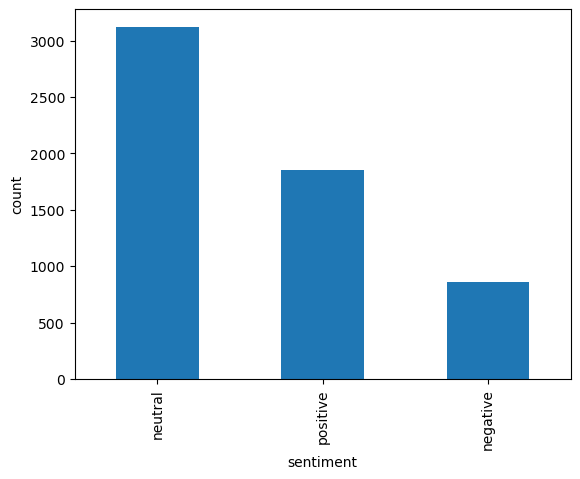

In [15]:
df.sentiment.value_counts().plot(kind='bar')
plt.ylabel("count") 


# is this representative? 


Is the imbalance representative? 




In [16]:
from imblearn.over_sampling import RandomOverSampler



In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import spacy

In [18]:
stop_words = list(set(stopwords.words('english')))
nlp = spacy.load("en_core_web_sm")

import sys 
sys.path.append("../scripts/")
from preprocessing import lemmatize
vectoriser = TfidfVectorizer(lowercase=True, stop_words=stop_words, strip_accents='unicode', max_features=100000, tokenizer=lemmatize, ngram_range=(1,20))

# model training

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score 
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

In [20]:
df.columns

Index(['unnamed: 0', 'sentence', 'sentiment', 'sentiment_encoded'], dtype='object')

In [21]:
X = df.drop(['sentiment', 'sentiment_encoded', 'unnamed: 0'], axis=1)
y = df.sentiment_encoded.values.reshape(-1,1)


ros = RandomOverSampler()


X_res, y_res = ros.fit_resample(X, y)

y_res = np.reshape(y_res, (-1,1))

X_train, X_test, Y_train, Y_test = train_test_split(X_res, y_res, test_size=0.2)


# fitting tfidf

X_train_tfidf = vectoriser.fit_transform(X_train.sentence) 
X_test_tfidf = vectoriser.transform(X_test.sentence) 




/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'ve", 'could', 'far', 'might', 'must', 'need', 'shall', 'win', 'would'] not in stop_words.
  warnings.warn(


In [22]:
df_res = pd.concat([X_res, pd.DataFrame(y_res)], axis=1)
df_res.columns=['sentence', 'sentiment']

<Axes: xlabel='sentiment'>

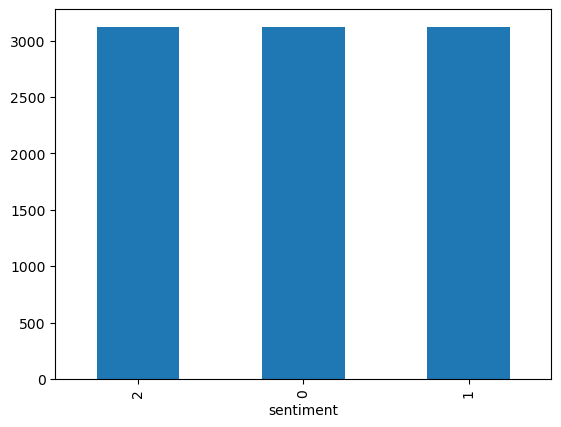

In [23]:
df_res.sentiment.value_counts().plot(kind='bar')

In [32]:
model = XGBClassifier(max_depth=20, eta=0.1) 

model.fit(X_train_tfidf, Y_train)


pred = model.predict(X_test_tfidf) 
train_pred = model.predict(X_train_tfidf)

# metrics

In [25]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay, confusion_matrix

In [33]:
print ("test metrics")
pred = model.predict(X_test_tfidf)
print (f"accuracy: {accuracy_score(y_true=Y_test, y_pred=pred)}")
print (f"f1 score weighted: {f1_score(y_pred=pred, y_true=Y_test, average='weighted')}")
print (f"f1 score micro: {f1_score(y_pred=pred, y_true=Y_test, average='micro')}")
print (f"f1 score macro: {f1_score(y_pred=pred, y_true=Y_test, average='macro')}")

print (f"precision score macro: {precision_score(y_pred=pred, y_true=Y_test, average='macro')}")

test metrics
accuracy: 0.8202666666666667
f1 score weighted: 0.8191957689903133
f1 score micro: 0.8202666666666667
f1 score macro: 0.818958698262161
precision score macro: 0.8209296052212837


In [34]:
print ("Training metrics")

train_pred = model.predict(X_train_tfidf)
print (f"accuracy: {accuracy_score(y_true=Y_train, y_pred=train_pred)}")
print (f"f1 score weighted: {f1_score(y_pred=train_pred, y_true=Y_train, average='weighted')}")
print (f"f1 score micro: {f1_score(y_pred=train_pred, y_true=Y_train, average='micro')}")
print (f"f1 score macro: {f1_score(y_pred=train_pred, y_true=Y_train, average='macro')}")

print (f"precision score macro: {precision_score(y_pred=train_pred, y_true=Y_train, average='macro')}")

Training metrics
accuracy: 0.9270374816593304
f1 score weighted: 0.9267431606412273
f1 score micro: 0.9270374816593304
f1 score macro: 0.9266455116445642
precision score macro: 0.9324157327773982


In [28]:
# optimising


from skopt import BayesSearchCV

from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.metrics import hamming_loss
from sklearn.multioutput import ClassifierChain

In [29]:
Y_train

array([[2],
       [0],
       [2],
       ...,
       [0],
       [2],
       [2]])

In [30]:
import gc 
gc.collect()

897

In [31]:
params = {
    'max_depth': [20, 50, 80],
    'eta': [0.1, 0.3],
    'min_child_weight': [0,1],
    'tree_method': ['exact']
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(),
    param_grid=params,
    verbose=3,
    return_train_score=True,
    cv=5,
    n_jobs=-1
)

_ = grid_search.fit(X_train_tfidf, Y_train) 


pred = grid_search.predict(X_test_tfidf) 


print ("testing scores...")
print (f"accuracy: {accuracy_score(y_true=Y_test, y_pred=pred)}")
print ("--------------------------------")
print (f"f1 score weighted: {f1_score(y_pred=pred, y_true=Y_test, average='weighted')}")
print (f"precision score weighted: {precision_score(y_pred=pred, y_true=Y_test, average='weighted')}")
print (f"recall score weighted: {recall_score(y_pred=pred, y_true=Y_test, average='weighted')}")

print ("--------------------------------")
print (f"f1 score micro: {f1_score(y_pred=pred, y_true=Y_test, average='micro')}")
print (f"precision score micro: {precision_score(y_pred=pred, y_true=Y_test, average='micro')}")
print (f"recall score micro: {recall_score(y_pred=pred, y_true=Y_test, average='micro')}")


print ("--------------------------------")
print (f"f1 score macro: {f1_score(y_pred=pred, y_true=Y_test, average='macro')}")
print (f"precision score macro: {precision_score(y_pred=pred, y_true=Y_test, average='macro')}")
print (f"recall score macro: {recall_score(y_pred=pred, y_true=Y_test, average='macro')}")



Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

[CV 2/5] END eta=0.1, max_depth=20, min_child_weight=1, tree_method=exact;, score=(train=0.927, test=0.811) total time= 1.5min
[CV 3/5] END eta=0.1, max_depth=20, min_child_weight=1, tree_method=exact;, score=(train=0.927, test=0.837) total time= 1.5min
[CV 1/5] END eta=0.1, max_depth=20, min_child_weight=1, tree_method=exact;, score=(train=0.926, test=0.832) total time= 1.5min
[CV 1/5] END eta=0.1, max_depth=20, min_child_weight=0, tree_method=exact;, score=(train=0.932, test=0.839) total time= 2.5min
[CV 4/5] END eta=0.1, max_depth=20, min_child_weight=0, tree_method=exact;, score=(train=0.933, test=0.829) total time= 2.6min
[CV 3/5] END eta=0.1, max_depth=20, min_child_weight=0, tree_method=exact;, score=(train=0.934, test=0.833) total time= 2.6min
[CV 5/5] END eta=0.1, max_depth=20, min_child_weight=0, tree_method=exact;, score=(train=0.935, test=0.825) total time= 2.6min
[CV 2/5] END eta=0.1, max_depth=20, min_child_weight=0, tree_method=exact;, score=(train=0.935, test=0.816) tot

In [294]:
grid_search.best_score_

0.8363327551701134

In [288]:
print (f"accuracy: {accuracy_score(y_true=Y_test, y_pred=pred)}")

accuracy: 0.8474666666666667


In [290]:
pred = model.predict(X_train_tfidf)

In [291]:
print ("training scores...")
print (f"accuracy: {accuracy_score(y_true=Y_train, y_pred=pred)}")
print ("--------------------------------")
print (f"f1 score weighted: {f1_score(y_pred=pred, y_true=Y_train, average='weighted')}")
print (f"precision score weighted: {precision_score(y_pred=pred, y_true=Y_train, average='weighted')}")
print (f"recall score weighted: {recall_score(y_pred=pred, y_true=Y_train, average='weighted')}")

print ("--------------------------------")
print (f"f1 score micro: {f1_score(y_pred=pred, y_true=Y_train, average='micro')}")
print (f"precision score micro: {precision_score(y_pred=pred, y_true=Y_train, average='micro')}")
print (f"recall score micro: {recall_score(y_pred=pred, y_true=Y_train, average='micro')}")


print ("--------------------------------")
print (f"f1 score macro: {f1_score(y_pred=pred, y_true=Y_train, average='macro')}")
print (f"precision score macro: {precision_score(y_pred=pred, y_true=Y_train, average='macro')}")
print (f"recall score macro: {recall_score(y_pred=pred, y_true=Y_train, average='macro')}")



training scores...
accuracy: 0.903828197945845
--------------------------------
f1 score weighted: 0.9034126397861779
precision score weighted: 0.90861335808708
recall score weighted: 0.903828197945845
--------------------------------
f1 score micro: 0.903828197945845
precision score micro: 0.903828197945845
recall score micro: 0.903828197945845
--------------------------------
f1 score macro: 0.9037327343138072
precision score macro: 0.90919860223106
recall score macro: 0.903844236978443


In [129]:
df.to_csv("../sentiment_analysis_data/financial_news.csv")

In [292]:
pred = model.predict(X_test_tfidf)

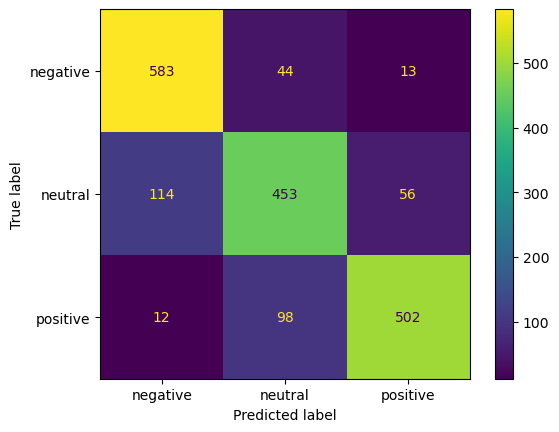

In [35]:
# confusion matrix

confusionmatrix = confusion_matrix(y_true=Y_test, y_pred = pred)

ConfusionMatrixDisplay(confusion_matrix=confusionmatrix, display_labels=['negative', 'neutral', 'positive']).plot()

In [381]:
df

,sentence,sentiment,sentiment_encoded,sentence_cleaned
0,The GeoSolutions technology will leverage Bene...,positive,2,The GeoSolutions technology will leverage Bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,0,ESI on lows down 1.50 to 2.50 BK a real po...
2,"For the last quarter of 2010 , Componenta 's n...",positive,2,For the last quarter of 2010 Componenta s n...
3,According to the Finnish-Russian Chamber of Co...,neutral,1,According to the Finnish Russian Chamber of Co...
4,The Swedish buyout firm has sold its remaining...,neutral,1,The Swedish buyout firm has sold its remaining...
...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,0,RISING costs have forced packaging producer Hu...
5838,Nordic Walking was first used as a summer trai...,neutral,1,Nordic Walking was first used as a summer trai...
5839,"According shipping company Viking Line , the E...",neutral,1,According shipping company Viking Line the E...
5840,"In the building and home improvement trade , s...",neutral,1,In the building and home improvement trade s...


In [37]:
import joblib

In [38]:
joblib.dump(model, '../models/sentiment_analyser/sentiment_analyser.pkl')
joblib.dump(vectoriser, '../models/sentiment_analyser/sentiment_vectoriser.pkl')

['../models/sentiment_analyser/sentiment_vectoriser.pkl']

In [126]:
X

,sentence
0,The GeoSolutions technology will leverage Bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po..."
2,"For the last quarter of 2010 , Componenta 's n..."
3,According to the Finnish-Russian Chamber of Co...
4,The Swedish buyout firm has sold its remaining...
...,...
5837,RISING costs have forced packaging producer Hu...
5838,Nordic Walking was first used as a summer trai...
5839,"According shipping company Viking Line , the E..."
5840,"In the building and home improvement trade , s..."


In [127]:
y

array([[2],
       [0],
       [2],
       ...,
       [1],
       [1],
       [2]])

# loading the model

In [96]:
import joblib 

In [116]:
model = joblib.load("../models/sentiment_analyser/sentiment_analyser.pkl")
vectoriser = joblib.load("../models/sentiment_analyser/sentiment_vectoriser.pkl")

In [117]:
vectoriser

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'unicode'
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,"[""couldn't"", ""she'll"", ...]"
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [119]:
X_tfidf = vectoriser.transform(X)

In [125]:
np.shape(X_tfidf.toarray())

(1, 10199)

In [123]:
np.shape(y)

(5836, 1)

In [107]:
import shap

In [114]:
np.unique(X_test_tfidf.toarray())

array([0.])

In [128]:
text = 'stock market value has dropped by 100%'

text_tfidf = vectoriser.transform([text]) 

model.predict(text_tfidf)

array([1])

In [130]:
text_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [299]:
df

,unnamed: 0,sentence,sentiment,sentiment_encoded
0,0,The GeoSolutions technology will leverage Bene...,positive,2
1,1,ESI on lows down to BK a real pos...,negative,0
2,2,For the last quarter of Componenta s n...,positive,2
3,3,According to the Finnish Russian Chamber of Co...,neutral,1
4,4,The Swedish buyout firm has sold its remaining...,neutral,1
...,...,...,...,...
5831,5837,RISING costs have forced packaging producer Hu...,negative,0
5832,5838,Nordic Walking was first used as a summer trai...,neutral,1
5833,5839,According shipping company Viking Line the E...,neutral,1
5834,5840,In the building and home improvement trade s...,neutral,1


# attempting pytorch

I will also create word embeddings

In [365]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader 

import torch.nn.functional as F
import torch.optim as optim

from collections import Counter
from sklearn.neural_network import MLPClassifier

In [369]:
X_train, X_test, Y_train, Y_test = train_test_split(X_res, y_res, test_size=0.2)

In [370]:
X_train

,sentence
5701,ENDP we saw a large order in this one last w...
1504,Russia s Video International Group holds a co...
5181,The company is well positioned in Brazil and U...
8900,Most bullish stocks on Twitter during this dip...
5250,The real estate company posted a net loss of ...
...,...
4568,By the end of the number of joint branc...
5318,The deal also includes a ten year maintenance ...
4675,AAPL Right back in Buy the dips brought ...
4734,GlaxoSmithKline share price slips as FDA okays...


In [371]:
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter

# ── 1. Build vocabulary ───────────────────────────────────────────────────────
def build_vocab(texts):
    tokens = [word for text in texts for word in text.lower().split()]
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(Counter(tokens).items())}
    vocab['<PAD>'] = 0  # padding token
    vocab['<UNK>'] = 1  # unknown token
    return vocab

vocab = build_vocab(X_train['sentence'])

# ── 2. Convert text to token IDs ──────────────────────────────────────────────
def text_to_ids(text, vocab, max_len=10):
    tokens = text.lower().split()
    ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    ids = ids[:max_len] + [vocab['<PAD>']] * max(0, max_len - len(ids))
    return ids

X_train['token_ids'] = X_train['sentence'].apply(lambda x: text_to_ids(x, vocab))
X_test['token_ids'] = X_test['sentence'].apply(lambda x: text_to_ids(x, vocab))

# ── 3. Convert to tensor ──────────────────────────────────────────────────────
train_tensor = torch.tensor(X_train['token_ids'].tolist(), dtype=torch.long)
test_tensor = torch.tensor(X_test['token_ids'].tolist(), dtype=torch.long) 

# ── 4. Define the embedding layer ─────────────────────────────────────────────
VOCAB_SIZE    = len(vocab)
EMBEDDING_DIM = 64
PADDING_IDX   = 0

embedding_layer = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PADDING_IDX
)

# ── 5. Generate embeddings ────────────────────────────────────────────────────
with torch.no_grad():
    train_embeddings = embedding_layer(train_tensor) 
    test_embeddings = embedding_layer(test_tensor)



# ── 6. Mean pooling over non-padding tokens ───────────────────────────────────
def mean_pool(embeddings, token_tensor):
    mask = (token_tensor != 0).unsqueeze(-1).float() 
    return (embeddings * mask).sum(dim=1) / mask.sum(dim=1)

train_sentence_embeddings = mean_pool(train_embeddings, train_tensor)
test_sentence_embeddings  = mean_pool(test_embeddings,  test_tensor)

X_train['embedding'] = train_sentence_embeddings.tolist()
X_test['embedding'] = test_sentence_embeddings.tolist()

In [372]:
X_train

,sentence,token_ids,embedding
5701,ENDP we saw a large order in this one last w...,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[0.1514764130115509, -0.2255893498659134, 0.29..."
1504,Russia s Video International Group holds a co...,"[21, 18, 22, 23, 24, 25, 5, 26, 27, 8]","[-0.0031657181680202484, -0.01846305839717388,..."
5181,The company is well positioned in Brazil and U...,"[31, 32, 33, 34, 35, 8, 36, 37, 38, 0]","[-0.2329268753528595, -0.1607578843832016, 0.3..."
8900,Most bullish stocks on Twitter during this dip...,"[39, 40, 41, 42, 43, 44, 9, 45, 46, 47]","[-0.38510510325431824, 0.15325471758842468, 0...."
5250,The real estate company posted a net loss of ...,"[31, 61, 62, 32, 63, 5, 64, 65, 66, 67]","[-0.4168315529823303, 0.2814610004425049, -0.7..."
...,...,...,...
4568,By the end of the number of joint branc...,"[104, 31, 803, 66, 31, 437, 66, 1968, 2951, 90]","[-0.20493873953819275, -0.1491723656654358, 0...."
5318,The deal also includes a ten year maintenance ...,"[31, 245, 14, 2742, 5, 5050, 125, 182, 325, 0]","[-0.4757012724876404, 0.5842549800872803, -0.5..."
4675,AAPL Right back in Buy the dips brought ...,"[1218, 873, 522, 8, 521, 31, 1322, 2289, 86, 644]","[-0.4499497413635254, -0.027358990162611008, 0..."
4734,GlaxoSmithKline share price slips as FDA okays...,"[1280, 70, 480, 5410, 188, 1984, 5411, 4018, 5...","[-0.1926065981388092, -0.26965025067329407, -0..."


In [373]:
X_train = X_train.drop(['sentence', 'token_ids'],axis=1)
X_test = X_test.drop(['sentence', 'token_ids'],axis=1)

In [374]:
X_train

,embedding
5701,"[0.1514764130115509, -0.2255893498659134, 0.29..."
1504,"[-0.0031657181680202484, -0.01846305839717388,..."
5181,"[-0.2329268753528595, -0.1607578843832016, 0.3..."
8900,"[-0.38510510325431824, 0.15325471758842468, 0...."
5250,"[-0.4168315529823303, 0.2814610004425049, -0.7..."
...,...
4568,"[-0.20493873953819275, -0.1491723656654358, 0...."
5318,"[-0.4757012724876404, 0.5842549800872803, -0.5..."
4675,"[-0.4499497413635254, -0.027358990162611008, 0..."
4734,"[-0.1926065981388092, -0.26965025067329407, -0..."


In [397]:
Y_train_tensor = torch.tensor(Y_train)
Y_test_tensor = torch.tensor(Y_test)
# ── Fix: squeeze out the extra dimension ──────────────────────────────────────
Y_train_tensor = Y_train_tensor.squeeze(1)  # (n, 1) → (n,)
Y_test_tensor  = Y_test_tensor.squeeze(1)

# ── Also ensure dtype is long ─────────────────────────────────────────────────
Y_train_tensor = Y_train_tensor.long()
Y_test_tensor  = Y_test_tensor.long()

X_train_tensor = torch.tensor(
    np.stack(X_train['embedding'].values), dtype=torch.float32
)
X_test_tensor = torch.tensor(
    np.stack(X_test['embedding'].values), dtype=torch.float32
)

In [400]:
Y_train_tensor

tensor([2, 1, 2,  ..., 2, 0, 2])

In [386]:
X_train_tensor

tensor([[ 0.1515, -0.2256,  0.2929,  ..., -0.2465, -0.0281, -0.3739],
        [-0.0032, -0.0185,  0.1504,  ..., -0.0829,  0.4493, -0.1178],
        [-0.2329, -0.1608,  0.3510,  ...,  0.1550, -0.1979, -0.2437],
        ...,
        [-0.4499, -0.0274,  0.5567,  ..., -0.1321, -0.2637, -0.3540],
        [-0.1926, -0.2697, -0.1286,  ...,  0.2156, -0.0695,  0.1767],
        [-0.8586, -0.2890, -0.1345,  ..., -0.1162,  0.1652, -0.5476]])

In [414]:
class Classifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super(Classifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # 64 → 128
            nn.ReLU(),
            nn.Dropout(dropout),


            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),


            nn.Linear(hidden_dim, hidden_dim // 2),  # 128 → 64
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, num_classes)  # 64 → num_classes
        )

    def forward(self, x):
        return self.network(x)  # raw logits (no softmax — handled by loss fn)

INPUT_DIM=64
HIDDEN_DIM=128
NUM_CLASSES=3

model = Classifier(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES) 
criterion=nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 



In [415]:
from torch.utils.data import DataLoader, TensorDataset

EPOCHS = 100

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()                # clear gradients
        logits = model(X_batch)              # forward pass
        loss   = criterion(logits, y_batch)  # compute loss
        loss.backward()                      # backprop
        optimizer.step()                     # update weights

        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()

    acc = correct / len(Y_train_tensor)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss:.4f} | Train Acc: {acc:.4f}")

Epoch 1/100 | Loss: 254.3930 | Train Acc: 0.3840
Epoch 2/100 | Loss: 247.7938 | Train Acc: 0.4303
Epoch 3/100 | Loss: 243.8699 | Train Acc: 0.4472
Epoch 4/100 | Loss: 239.3380 | Train Acc: 0.4613
Epoch 5/100 | Loss: 236.0106 | Train Acc: 0.4729
Epoch 6/100 | Loss: 232.0837 | Train Acc: 0.4890
Epoch 7/100 | Loss: 226.9600 | Train Acc: 0.5003
Epoch 8/100 | Loss: 225.1216 | Train Acc: 0.5119
Epoch 9/100 | Loss: 221.0853 | Train Acc: 0.5179
Epoch 10/100 | Loss: 218.0048 | Train Acc: 0.5277
Epoch 11/100 | Loss: 213.7469 | Train Acc: 0.5345
Epoch 12/100 | Loss: 212.0493 | Train Acc: 0.5526
Epoch 13/100 | Loss: 208.1079 | Train Acc: 0.5572
Epoch 14/100 | Loss: 206.3643 | Train Acc: 0.5648
Epoch 15/100 | Loss: 202.3391 | Train Acc: 0.5692
Epoch 16/100 | Loss: 201.6161 | Train Acc: 0.5936
Epoch 17/100 | Loss: 195.9025 | Train Acc: 0.6162
Epoch 18/100 | Loss: 189.7151 | Train Acc: 0.6364
Epoch 19/100 | Loss: 186.6834 | Train Acc: 0.6511
Epoch 20/100 | Loss: 183.5054 | Train Acc: 0.6596
Epoch 21/

In [416]:
model.eval()  # switch off dropout

with torch.no_grad():  # no gradient computation needed for inference
    logits      = model(X_test_tensor)           # raw scores, shape (n, num_classes)
    probs       = torch.softmax(logits, dim=1)   # convert to probabilities
    predictions = logits.argmax(dim=1)           # predicted class index

# ── Decode back to original labels ───────────────────────────────────────────


In [417]:
predictions

tensor([2, 2, 0,  ..., 2, 2, 2])

In [418]:
accuracy_score(predictions, Y_test)

0.7157333333333333

In [419]:
# using xbgoost with embeddings

clf = XGBClassifier() 

clf.fit(X_train_tensor, Y_train_tensor) 

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [420]:
pred = clf.predict(X_test_tensor)

In [422]:
accuracy_score(y_true=Y_test_tensor, y_pred=pred)

0.7664

In [423]:
params = {
    'max_depth': [6, 10, 20, 50, 80],
    'eta': [0.1, 0.3, 0.2, 0.15, 0.25, 0.001, 0.01, 0.02, 0.03],
    'min_child_weight': [0,1],
    'tree_method': ['exact']
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(),
    param_grid=params,
    verbose=3,
    return_train_score=True,
    cv=5,
    n_jobs=-1
)

_ = grid_search.fit(X_train_tfidf, Y_train) 


pred = grid_search.predict(X_test_tfidf) 


print ("testing scores...")
print (f"accuracy: {accuracy_score(y_true=Y_test, y_pred=pred)}")
print ("--------------------------------")
print (f"f1 score weighted: {f1_score(y_pred=pred, y_true=Y_test, average='weighted')}")
print (f"precision score weighted: {precision_score(y_pred=pred, y_true=Y_test, average='weighted')}")
print (f"recall score weighted: {recall_score(y_pred=pred, y_true=Y_test, average='weighted')}")

print ("--------------------------------")
print (f"f1 score micro: {f1_score(y_pred=pred, y_true=Y_test, average='micro')}")
print (f"precision score micro: {precision_score(y_pred=pred, y_true=Y_test, average='micro')}")
print (f"recall score micro: {recall_score(y_pred=pred, y_true=Y_test, average='micro')}")


print ("--------------------------------")
print (f"f1 score macro: {f1_score(y_pred=pred, y_true=Y_test, average='macro')}")
print (f"precision score macro: {precision_score(y_pred=pred, y_true=Y_test, average='macro')}")
print (f"recall score macro: {recall_score(y_pred=pred, y_true=Y_test, average='macro')}")



Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END eta=0.1, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.643, test=0.346) total time=  34.8s
[CV 3/5] END eta=0.1, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.637, test=0.338) total time=  34.9s
[CV 2/5] END eta=0.1, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.638, test=0.327) total time=  35.5s
[CV 3/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.660, test=0.337) total time=  43.4s
[CV 5/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.665, test=0.306) total time=  44.1s
[CV 1/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.658, test=0.335) total time=  44.6s
[CV 4/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.663, test=0.334) total time=  44.5s
[CV 2/5] END eta=0.1, max_depth=6, min_child_weight=0, t

KeyboardInterrupt: 